<a href="https://colab.research.google.com/github/chigur-DA/b2b-sales-pipeline-analysis/blob/main/stat_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()
client = bigquery.Client(project='b2b-sales-pipeline-crm')
query = """ SELECT
   opportunity_id,
   sp.`account`as account,
   a.sector as sector,
  DATE_DIFF(close_date,engage_date, DAY) AS sales_cycle_days,
  `close_value`,
  CASE WHEN  sp.deal_stage = 'Won' THEN 1
        WHEN sp.deal_stage = 'Lost' THEN 0
        ELSE NULL END AS is_won,
  sp.`product` as product,
  p.series as product_series,
  sp.`sales_agent`as sales_agent,
  st.regional_office as sales_agent_regional_office


FROM `sales_data.sales_pipeline` sp
LEFT JOIN `sales_data.products` p
ON sp.product = p.product
LEFT JOIN `sales_data.accounts` a
ON sp.account=a.account
LEFT JOIN `sales_data.sales_teams` st
ON sp.sales_agent=st.sales_agent
WHERE sp.deal_stage IN ('Won','Lost')
AND close_value IS NOT NULL
"""

df = client.query(query).to_dataframe()
df.head()

,opportunity_id,account,sector,sales_cycle_days,close_value,is_won,product,product_series,sales_agent,sales_agent_regional_office
0,8SOQADK7,Gogozoom,telecommunications,136,0,0,MG Special,MG,Anna Snelling,Central
1,K53BC1T9,Domzoom,entertainment,121,0,0,MG Special,MG,Anna Snelling,Central
2,3X13866U,dambase,marketing,95,0,0,GTX Plus Basic,GTX,Anna Snelling,Central
3,SKY95DVG,Betatech,medical,103,0,0,MG Special,MG,Anna Snelling,Central
4,L62MDI48,Isdom,medical,71,0,0,MG Advanced,MG,Anna Snelling,Central


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6711 entries, 0 to 6710
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   opportunity_id               6711 non-null   object
 1   account                      6711 non-null   object
 2   sector                       6711 non-null   object
 3   sales_cycle_days             6711 non-null   Int64 
 4   close_value                  6711 non-null   Int64 
 5   is_won                       6711 non-null   Int64 
 6   product                      6711 non-null   object
 7   product_series               5564 non-null   object
 8   sales_agent                  6711 non-null   object
 9   sales_agent_regional_office  6711 non-null   object
dtypes: Int64(3), object(7)
memory usage: 544.1+ KB


In [ ]:
df.describe()

,sales_cycle_days,close_value,is_won
count,6711.0,6711.0,6711.0
mean,47.985397,1490.915512,0.631501
std,41.057665,2320.670773,0.482434
min,1.0,0.0,0.0
25%,8.0,0.0,0.0
50%,45.0,472.0,1.0
75%,85.0,3225.0,1.0
max,138.0,30288.0,1.0


# H0: Data follows a normal distribution
# H1: Data does not follow a normal distribution

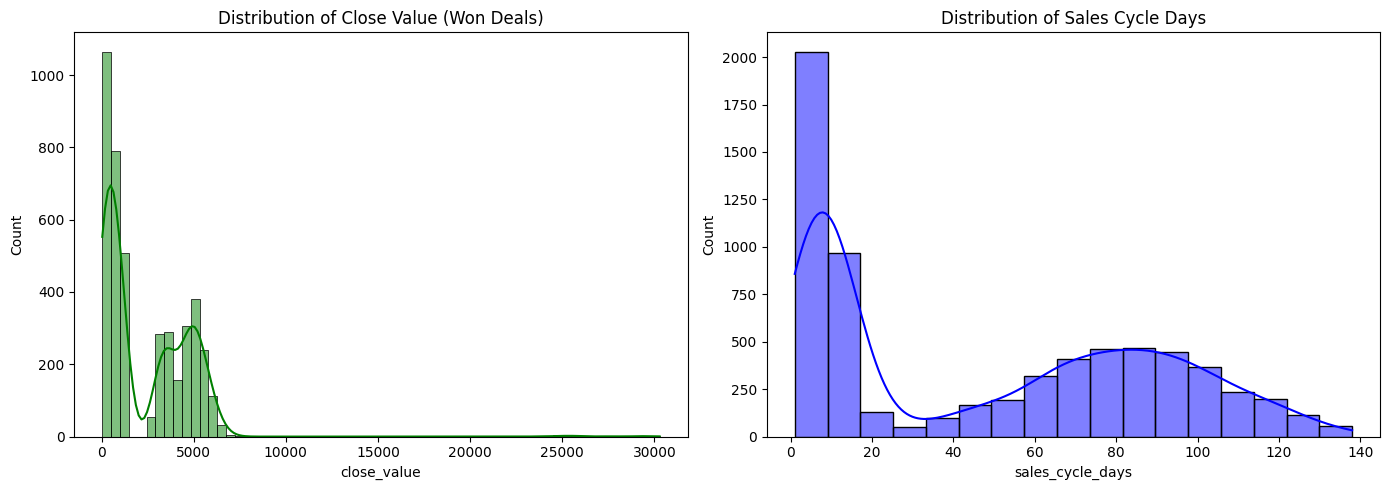

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['is_won'] == 1]['close_value'], kde=True, ax=axes[0], color='green')
axes[0].set_title('Distribution of Close Value (Won Deals)')

sns.histplot(df['sales_cycle_days'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Distribution of Sales Cycle Days')

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
stat_val, p_val_value = stats.normaltest(df['close_value'])
stat_days, p_val_days = stats.normaltest(df['sales_cycle_days'])

print(f"Close Value p-value: {p_val_value}")
print(f"Sales Cycle Days p-value: {p_val_days}")

Close Value p-value: 0.0
Sales Cycle Days p-value: 0.0


*Since p-value < 0.05, we reject the null hypothesis of normality for both metrics. The data exhibits significant skewness and bimodal distribution.Methodological Decision: We replace standard parametric tests (Student's t-test) with non-parametric methods (Mann-Whitney U test for two-group comparisons and Kruskal-Wallis test for multi-sector comparison).

# H0: The distribution of sales_cycle_days is the same for won and lost deals.
# H1: The distribution of sales_cycle_days differs significantly between won and lost deals.

In [ ]:
from scipy import stats
won_cycle = df[df['is_won'] == 1]['sales_cycle_days']
lost_cycle = df[df['is_won'] == 0]['sales_cycle_days']
print(f"Median Sales Cycle (Won): {won_cycle.median():.1f} days")
print(f"Median Sales Cycle (Lost): {lost_cycle.median():.1f} days")

Median Sales Cycle (Won): 57.0 days
Median Sales Cycle (Lost): 14.0 days


In [ ]:
# Mann-Whitney U test
u_stat, p_val = stats.mannwhitneyu(won_cycle, lost_cycle, alternative='two-sided')
print(f"\nMann-Whitney U statistic: {u_stat}")
print(f"p-value: {p_val}")


Mann-Whitney U statistic: 6057932.0
p-value: 1.2294240381986664e-26


* Since p-vaule < 0.05, we reject the null hypothesis ($H_0$). There is a statistically significant difference in the sales cycle duration between won and lost deals.
* Won deals take significantly longer to close than lost deals. This indicates that sales teams qualify out unresponsive or unsuitable prospects quickly (within two weeks), while successful deals require a longer conversion cycle (approx. 2 months) of negotiation and relationship building.

# H0 : The distribution of close_value for lost deals is less than or equal to that of won deals.

# H1 : The distribution of close_value for lost deals is statistically significantly higher than for won deals (indicating potential overpricing).

In [ ]:
won_value = df[df['is_won'] == 1]['close_value']
lost_value = df[df['is_won'] == 0]['close_value']
print(f"Median Close Value (Won): ${won_value.median():,.2f}")
print(f"Median Close Value (Lost): ${lost_value.median():,.2f}")

u_stat, p_val = stats.mannwhitneyu(lost_value, won_value, alternative='greater')
print(f"\nMann-Whitney U statistic: {u_stat}")
print(f"p-value: {p_val}")

Median Close Value (Won): $1,117.00
Median Close Value (Lost): $0.00

Mann-Whitney U statistic: 0.0
p-value: 1.0


* The dataset currently records financial outcomes (close_value) rather than commercial proposals (pipeline_value). To evaluate pricing sensitivity, sales operations should introduce a dedicated quoted_amount tracking field in the CRM pipeline

# H 0: Deal outcome (is_won) is independent of the market sector (sector). The conversion rate does not significantly differ across industries.
# H 1: Deal outcome (is_won) is statistically dependent on the market sector (sector). Win rate varies significantly depending on the client's industry.

In [ ]:
from scipy import stats
import pandas as pd

# Contingency Table
contingency_table = pd.crosstab(df['sector'], df['is_won'])
print("Contingency Tab")
print(contingency_table)

Contingency Tab
is_won                0    1
sector                      
employment          107  179
entertainment       142  260
finance             238  375
marketing           219  404
medical             358  592
retail              468  799
services            129  223
software            254  450
technolgy           387  671
telecommunications  171  285


In [ ]:
win_rates = df.groupby('sector')['is_won'].mean() * 100
print(" Win Rate  (%)")
print(win_rates.round(2))

 Win Rate  (%)
sector
employment            62.59
entertainment         64.68
finance               61.17
marketing             64.85
medical               62.32
retail                63.06
services              63.35
software              63.92
technolgy             63.42
telecommunications     62.5
Name: is_won, dtype: Float64


In [ ]:
# Chi-Square Test of Independence
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val}")
print(f"Degrees of freedom: {dof}")

Chi-Square
Chi-square statistic: 2.8313
p-value: 0.9706100917948224
Degrees of freedom: 9


* Statistical Insight: There is no statistically significant relationship between client sector and deal success rate. Any slight variance in Win Rate across sectors is purely attributable to random noise.
* Strategic Implication: Product-market fit and sales effectiveness are uniform across all targeted industries. Sales leadership should not restrict outreach or reallocate pipeline resources based on sector performance alone, as sector identity does not drive conversion outcomes.

# Correlation Analysis

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

won_deals = df[df['is_won'] == 1]
spearman_corr = won_deals[['sales_cycle_days', 'close_value']].corr(method='spearman')
print("Spearman Correlation Matrix (Won Deals Only)")
print(spearman_corr)

Spearman Correlation Matrix (Won Deals Only)
                  sales_cycle_days  close_value
sales_cycle_days          1.000000    -0.028354
close_value              -0.028354     1.000000


In [ ]:
corr_stat, p_val = stats.spearmanr(won_deals['sales_cycle_days'], won_deals['close_value'])
print(f"Spearman Correlation Coefficient: {corr_stat:.4f}")
print(f"p-value: {p_val}")

Spearman Correlation Coefficient: -0.0284
p-value: 0.06494411730871372


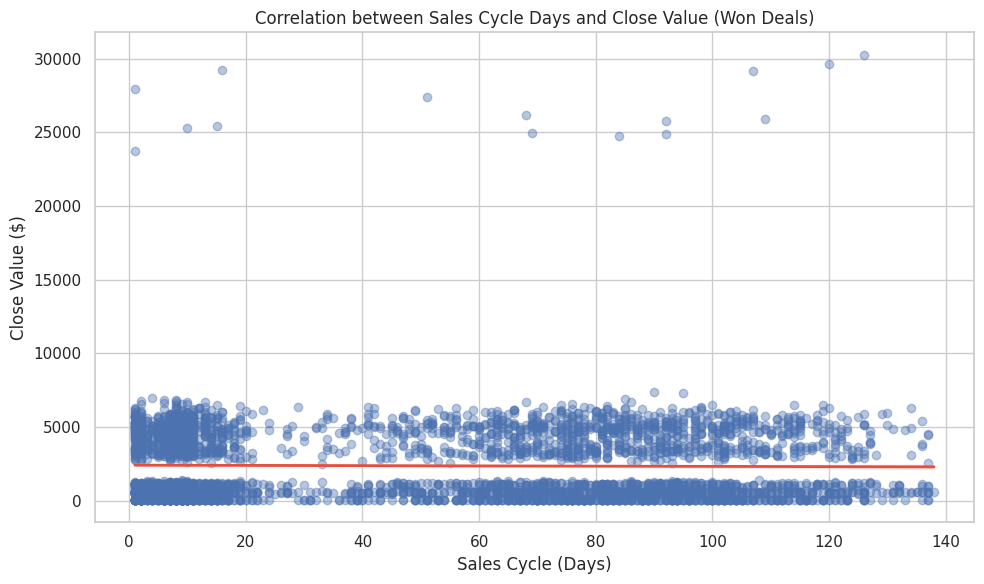

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.regplot(data=won_deals,
    x='sales_cycle_days',
    y='close_value',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': '#e74c3c', 'linewidth': 2})

plt.title('Correlation between Sales Cycle Days and Close Value (Won Deals)')
plt.xlabel('Sales Cycle (Days)')
plt.ylabel('Close Value ($)')

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig('sales_cycle_vs_value.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

* Correlation Between Deal Duration and Deal Size (r - 0):There is virtually no correlation between sales_cycle_days and close_value. This indicates that deal size does not dictate negotiation length—a small $500 deal can take anywhere from 2 to 120 days to close, and the exact same pattern applies to high-value deals.
* Lower Dense Band (0 - 1,500):Represents the highest concentration of deals, indicating the company's core mass-market product or standard deal size.
*  Secondary Band (3,000 -6,000):Highlights the second most common deal tier (likely a higher-tier package or a premium product line).
* Enterprise Outliers (20,000+):Large-value enterprise deals are rare, yet they are scattered evenly across the entire х-axis. They show no specific cycle length—some close rapidly within 20 days, while others stretch beyond 120 days.
* Early-Stage Clustering (0 to 20 Days):Distinct vertical columns appear in the early phase (0–20 days), showing that a significant volume of deals resolves very quickly within the first 2 to 3 weeks. Beyond 20 days, the distribution becomes markedly more dispersed.